# Atividade de vendas no Brasil

### Entregável 1 NumPy
### Entregável 2 Pandas
### Entregável 3 Seaborn

In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Entregável 1:

In [6]:

df = pd.read_csv('../../data/vendas_brasil_1.csv')
df.head(5) # printa as 5 primeiras linhas do dataframe
df.columns # printa as colunas do dataframe


Index(['data_venda', 'mes', 'cidade', 'canal_venda', 'categoria', 'produto',
       'vendedor', 'fidelidade_cliente', 'preco_unitario', 'custo_unitario',
       'margem_pct', 'quantidade', 'desconto_pct', 'receita_total', 'frete',
       'avaliacao_cliente', 'prazo_entrega_dias', 'devolucao',
       'entrega_no_prazo', 'alta_temporada', 'flag_outlier_preco'],
      dtype='str')

#### a) Criando arrays

In [7]:

## .to_numpy() transforma a coluna do dataframe em um array numpy

preco_unitario = df['preco_unitario'].to_numpy() 
custo_unitario = df['custo_unitario'].to_numpy()
quantidade = df['quantidade'].to_numpy()
desconto_pct = df['desconto_pct'].to_numpy()
receita_total = df['receita_total'].to_numpy()
frete = df['frete'].to_numpy()


#### b) Cálculos com operações vetorizadas

In [8]:

# 1) valor bruto da venda
valor_bruto_venda = preco_unitario * quantidade

# 2) valor do desconto
valor_desconto = valor_bruto_venda * desconto_pct

# 3) custo total
custo_total = custo_unitario * quantidade

# 4) lucro estimado
lucro_estimado = receita_total - (custo_total + frete) 

print("Valor bruto da venda:", np.sum(valor_bruto_venda))
print("Valor do desconto: ", np.sum(valor_desconto))
print("Custo total: ", np.sum(custo_total))
print("Lucro estimado: ", np.nansum(lucro_estimado))


Valor bruto da venda: 71506224.03
Valor do desconto:  678491546.658
Custo total:  51855072.87
Lucro estimado:  17239412.08


#### c) Máscaras booleanas

In [9]:

# vendas com receita acima da média
vendas_acima_media = receita_total > np.mean(receita_total)

# vendas com prejuízo
vendas_com_prejuizo = lucro_estimado < 0

# vendas com desconto alto
vendas_com_desconto_alto = desconto_pct > 0.5

print("Vendas com receita acima da média:", np.sum(vendas_acima_media))
print("Vendas com prejuízo:", np.sum(vendas_com_prejuizo)) 
print("Vendas com desconto alto:", np.sum(vendas_com_desconto_alto))



Vendas com receita acima da média: 9236
Vendas com prejuízo: 5857
Vendas com desconto alto: 26726


#### d) Agregações

In [10]:

# receita média
receita_media = np.mean(receita_total)

# maior receita
maior_receita = np.max(receita_total)

# menor receita
menor_receita = np.min(receita_total)

# lucro médio
## lucro_medio = np.mean(lucro_estimado)
## como tava dando nan e chequei que existem nan em lucro_estimado, vou calcular a média ignorando os nan
lucro_medio = np.nanmean(lucro_estimado)

# quantidade de vendas com prejuízo
quantidade_prejuizo = np.sum(lucro_estimado < 0) # = np.sum(vendas_com_prejuizo)

# vendo pq lucro médio estava resultando em nan
total_nulos_lucro = np.isnan(lucro_estimado).sum()



print("Receita média:", receita_media)
print("Maior receita:", maior_receita)
print("Menor receita:", menor_receita)
# print("Lucro médio:", lucro_medio) tava dando nan!
print("Lucro médio:", lucro_medio)
print(f"Quantidade de valores nulos em lucro_estimado: {total_nulos_lucro}")
print("Quantidade de vendas com prejuízo:", quantidade_prejuizo)

Receita média: 1891.6881729005502
Maior receita: 58430.28
Menor receita: 3.7
Lucro médio: 482.3832357714477
Quantidade de valores nulos em lucro_estimado: 1879
Quantidade de vendas com prejuízo: 5857


Conclusão geral sobre comportamento geral das vendas: 

O valor bruto de venda (ou seja, o preço unitário de cada produto multiplicado pelas quantidades correspondentes) foi de aproximadamente R$71506224,00
O valor do desconto total (valor bruto de venda multiplicado pelo percentual de descinto), foi de aproximadamente R$678491546,00
O custo total (custo unitário multiplicado pela quantidade) foi de aproximadamente R$51855072,00.

Foram 9236 vendas com receita acima da média (R$1891,70), 5857 vendas com prejuízo e 26726 vendas com desconto.


### Entrega 2:

#### a) Primeiro olhar no dataset

In [11]:
display(df.head()) # comando para visualizar as primeiras 5 linhas do dataframe
display(df.info()) # comando para visualizar informações sobre o dataframe (total de entradas, lista as colunas, quantos não nulos em cada e o tipo de dado)
display(df.describe()) # comando para visualizar estatísticas descritivas do dataframe (quantidade, média, desvio padrão, mínimo, máximo e quartis)
display(df.shape) # comando para visualizar a forma do dataframe (retorna tupla no formato (linhas, colunas))
display(df.isna().sum()) # comando para visualizar a soma dos valores nulos por coluna (cria tabela do mesmo tamanho da original, com True para valores nulos e False para não nulos, e soma os True por coluna)
## ou seja, as linhas com '0' são as colunas sem valores nulos

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

None

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


(37617, 21)

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

### 1. Quantas linhas e colunas existem?
    São 37617 linhas e 21 colunas.

### 2. Existem dados faltantes?
    Sim, como pode ser visto pelo display do comando df.isna().sum(), que mostra a soma dos True (onde não tem dados), as linhas que apresentam número diferente de zero são a soma desses 'True'.

### 3. Quais colunas parecem numéricas?
    Pelo display do comando df.info(), que mostra os tipos de dados, são 10 colunas numéricas, sendo 8 de float e 2 de int.
    
### 4. Quais colunas parecem categóricas?
    Pelo display do comando df.info(), são 7 colunas de string.

#### b) Limpeza e tratamento

In [12]:
# 1. converta a coluna de data para o tipo datetime

df['data_venda'] = pd.to_datetime(df['data_venda'], format = 'mixed')


In [13]:
# 2. padronize pelo menos uma coluna categórica que tenha valores escritos de formas diferentes

df['categoria'] = df['categoria'].str.strip().str.lower() # transforma todas as letras da coluna categoria em minúsculas e remove espaços em branco no início e no final da string

In [14]:
# 3. trate alguns dados faltantes de forma adequada

## vendo no display de df.isna().sum() que as colunas 'preco_unitario', 'custo_unitario', 'quantidade', 'desconto_pct', 'receita_total' e 'frete' possuem valores nulos, vou preencher esses valores com a média da coluna correspondente
df['preco-unitario'] = df['preco_unitario'].fillna(df['preco_unitario'].mean())
df['custo_unitario'] = df['custo_unitario'].fillna(df['custo_unitario'].mean())
df['quantidade'] = df['quantidade'].fillna(df['quantidade'].mean())
df['desconto_pct'] = df['desconto_pct'].fillna(df['desconto_pct'].mean())
df['receita_total'] = df['receita_total'].fillna(df['receita_total'].mean())
df['frete'] = df['frete'].fillna(df['frete'].mean())

## o comando .fillna preenche os valores nulos com o valor especificado, que nesse caso é a média da coluna correspondente.

Explicação das decisões tomadas: 
 
    Para converter a coluna de data para datetime, utilizei o comando pd.to_datetime para trasnformar as informações da coluna "data_venda" e tive que colocar que as datas do arquivo estavam organizadas no modo misturado, para o Pandas não assumir que todas as datas estão no mesmo padrão.  

    Padronizei a coluna "categoria", removendo os espaços em branco no início e fim das strings e também colocando todas as letras em minúsculo.  

    Tratei os dados númericos que estavam com valores nulos. Peguei a informação desses "buracos" pelo display do comando df.isna().sum, que pega as colunas e coloca 'True' nas que tem valor nulo e 'False' nas que não tem. O .sum() depois soma todos os 'True' (ou seja, os valores nulos). Para tratar esses nulos, decidi colocar a média dos valores das respectivas colunas utilizando o .fillna.
  
    
    

#### c) Criação de novas colunas

In [15]:
# 1. ano da venda
df['ano_venda'] = df['data_venda'].dt.year # cria a coluna 'ano_venda' no dataframe, que contém o ano da venda extraído da coluna 'data_venda'

In [16]:
# 2. mês da venda
df['mes_venda'] = df['data_venda'].dt.month # cria a coluna 'mes_venda' no dataframe, que contém o mês da venda extraído da coluna 'data_venda'

In [17]:
# 3. lucro total

## pra conseguir fazer a coluna do lucro total, primeiro tentei fazer igual ao começo onde só calculei o valor do lucro estimado
## como aqui estou trabalhando com as colunas do dataframe, tive que antes criar a coluna do custo total para esses valor em coluna poderem ser usados na nova coluna de lucro!
df['custo_total'] = df['custo_unitario'] * df['quantidade'] # cria a coluna 'custo_total' no dataframe, que contém o custo total da venda, calculado como custo unitário vezes quantidade
df['lucro_total'] = df['receita_total'] - df['custo_total'] - df['frete'] # cria a coluna 'lucro_total' no dataframe, que contém o lucro total da venda, calculado como receita total menos custo total e frete

In [18]:
# 4. receita líquida

df['receita_liquida'] = df['receita_total'] * (1-df['desconto_pct']) - df['frete'] # cria a coluna 'receita_liquida' no dataframe, que contém a receita líquida da venda, calculada como a receita total menos o frete

In [19]:
# 5. vendas acima da média (usando apply e lambda)

## apply é para aplicar uma função a cada elemento de uma coluna do dataframe, e lambda é uma função para definir a regra de transformação de cada célula da coluna. 
## Nesse caso, a função lambda retorna 1 se o valor da receita for maior que a média da receita, e 0 caso contrário. O resultado é uma nova coluna 'vendas_acima_media' no dataframe, que indica se cada venda teve receita acima da média ou não.
df['vendas_acima_media'] = df['receita_total'].apply(lambda x: 1 if x > df['receita_total'].mean() else 0)

#### d) Filtros

In [34]:
# 1. Quais vendas tiveram receita acima de determinado valor?
valor_determinado = 1000  # exemplo de valor determinado
vendas_acima_valor = df[df['receita_total'] > valor_determinado]
print("Vendas com receita acima de", valor_determinado, ":", vendas_acima_valor)
qntd_vendas_acima_valor = df[df['receita_total'] > valor_determinado].shape[0]  # conta o número de linhas (vendas) com receita acima do valor determinado
print("Quantidade de vendas com receita acima de", valor_determinado, ":", qntd_vendas_acima_valor)

Vendas com receita acima de 1000 :       data_venda  mes          cidade  canal_venda    categoria  \
0     2022-04-13    4  Rio de Janeiro   App Mobile  eletrônicos   
2     2022-09-28    9         Goiânia   App Mobile    vestuário   
3     2022-04-17    4       Fortaleza     Site Web    vestuário   
10    2022-08-03    8    Porto Alegre  Marketplace    vestuário   
11    2022-11-27   11       São Paulo     Site Web     esportes   
...          ...  ...             ...          ...          ...   
37602 2023-12-31    3       São Paulo   App Mobile    vestuário   
37603 2023-12-31    9  Rio de Janeiro   App Mobile  eletrônicos   
37605 2023-12-31    3       Fortaleza  Marketplace     esportes   
37615 2023-12-31   11       São Paulo     Site Web     esportes   
37616 2023-12-31    4       Fortaleza   Televendas  eletrônicos   

              produto        vendedor fidelidade_cliente  preco_unitario  \
0            Notebook     Bruno Souza           Diamante          739.39   
2       

In [33]:
# 2. Quais vendas tiveram devolução?
vendas_devolvidas = df[df['devolucao'] == True]
print("Vendas com devolução:", vendas_devolvidas)
qntd_vendas_devolvidas = len(vendas_devolvidas)  # conta o número de linhas (vendas) com devolução
print("Quantidade de vendas com devolução:", qntd_vendas_devolvidas)

Vendas com devolução:       data_venda  mes          cidade  canal_venda    categoria  \
1     2023-03-12    3          Manaus     Site Web    vestuário   
2     2022-09-28    9         Goiânia   App Mobile    vestuário   
7     2023-09-07    9          Manaus   App Mobile  alimentação   
18    2023-10-24   10          Manaus     Site Web    vestuário   
21    2023-05-07    5       São Paulo  Loja Física  eletrônicos   
...          ...  ...             ...          ...          ...   
37522 2023-12-31   11        Salvador  Marketplace     esportes   
37525 2023-12-31   11        Curitiba  Loja Física     esportes   
37533 2023-12-31    5  Belo Horizonte   App Mobile  alimentação   
37583 2023-12-31    2          Manaus  Loja Física  eletrônicos   
37589 2023-12-31    4  Rio de Janeiro   App Mobile  eletrônicos   

              produto       vendedor fidelidade_cliente  preco_unitario  \
1            Camiseta    Elisa Costa             Bronze          187.48   
2               Tênis  

In [32]:
# 3. Quais vendas pertencem a uma categoria específica?
vendas_eletronicos = df[df['categoria'] == 'eletrônicos']
print("Vendas da categoria 'eletrônicos':", vendas_eletronicos)
qntd_vendas_eletronicos = df[df['categoria'] == 'eletrônicos'].shape[0]  # conta o número de linhas (vendas) na categoria 'eletrônicos'
print("Quantidade de vendas da categoria 'eletrônicos':", qntd_vendas_eletronicos)

Vendas da categoria 'eletrônicos':       data_venda  mes          cidade  canal_venda    categoria  \
0     2022-04-13    4  Rio de Janeiro   App Mobile  eletrônicos   
15    2022-04-10    4        Salvador  Marketplace  eletrônicos   
17    2022-05-11    5  Belo Horizonte   App Mobile  eletrônicos   
20    2022-12-10   12          Recife     Site Web  eletrônicos   
21    2023-05-07    5       São Paulo  Loja Física  eletrônicos   
...          ...  ...             ...          ...          ...   
37589 2023-12-31    4  Rio de Janeiro   App Mobile  eletrônicos   
37593 2023-12-31    2          Manaus     Site Web  eletrônicos   
37600 2023-12-31   12       Fortaleza   App Mobile  eletrônicos   
37603 2023-12-31    9  Rio de Janeiro   App Mobile  eletrônicos   
37616 2023-12-31    4       Fortaleza   Televendas  eletrônicos   

              produto       vendedor fidelidade_cliente  preco_unitario  \
0            Notebook    Bruno Souza           Diamante          739.39   
15        

#### e) Agrupamentos com groupby

In [35]:
# 1. Qual categoria teve maior receita total?

categoria_maior_receita = df.groupby('categoria')['receita_total'].sum().idxmax()
## o groupby agrupa o dataframe pela coluna 'categoria', e a função sum() soma a receita total de cada categoria. A função idxmax() retorna o índice (categoria) com o maior valor de receita total.
print("Categoria com maior receita total:", categoria_maior_receita)

Categoria com maior receita total: eletrônicos


In [ ]:
# 2. Qual canal de venda teve maior quantidade de vendas?

canal_maior_vendas = df.groupby('canal_venda').size().idxmax()
print("Canal com maior quantidade de vendas:", canal_maior_vendas)

## aqui tem que usar size em vez de sum pq sum() soma os valores da coluna, enquanto size() conta o número de linhas (vendas) em cada grupo. Como queremos a quantidade de vendas, usamos size().

Canal com maior quantidade de vendas: Site Web


In [37]:
# 3. Qual cidade teve maior receita?

cidade_maior_receita = df.groupby('cidade')['receita_total'].sum().idxmax()
print("Cidade com maior receita:", cidade_maior_receita)

Cidade com maior receita: Recife


In [39]:
# 4. Qual categoria tece maior lucro?

categoria_maior_lucro = df.groupby('categoria')['lucro_total'].sum().idxmax()
print("Categoria com maior lucro:", categoria_maior_lucro)

Categoria com maior lucro: eletrônicos


#### f) Merge

In [47]:
# Crie uma pequena tabela auxiliar manualmente e faça um merge com o dataset principal.

## pra realizar um merge (junção) de dados, precisa de uma "chave" comum entre as tabelas (uma coluna que exista em ambas e permita que o computador saiba qual linha corresponde a qual)

## criando tabela auxilixar
dados_regioes = {
    'cidade': ['Rio de Janeiro', 'São Paulo', 'Belo Horizonte', 'Curitiba', 'Porto Alegre', 'Fortaleza', 'Salvador', 'Manaus', 'Goiânia'],
    'regiao': ['Sudeste', 'Sudeste', 'Sudeste', 'Sul', 'Sul', 'Nordeste', 'Nordeste', 'Norte', 'Centro-Oeste']
}

df_regioes = pd.DataFrame(dados_regioes) # criei uma tabela com as cidades e suas respectivas regiões

## limpeza
df['cidade'] = df['cidade'].str.strip()
df_regioes['cidade'] = df_regioes['cidade'].str.strip()

## usando o merge, vou juntar a tabela df_regioes com o dataframe principal df, usando a coluna 'cidade' como chave.
df_merged = pd.merge(df, df_regioes, on = 'cidade', how='left') # left join, ou seja, todas as linhas do dataframe principal df serão mantidas (já que é a tabela da esquerda), e as informações da tabela auxiliar df_regioes serão adicionadas quando houver correspondência na coluna 'cidade' 
print("Dataframe após o merge:", df_merged)



Dataframe após o merge:       data_venda  mes          cidade  canal_venda    categoria  \
0     2022-04-13    4  Rio de Janeiro   App Mobile  eletrônicos   
1     2023-03-12    3          Manaus     Site Web    vestuário   
2     2022-09-28    9         Goiânia   App Mobile    vestuário   
3     2022-04-17    4       Fortaleza     Site Web    vestuário   
4     2022-03-13    3  Belo Horizonte   App Mobile     esportes   
...          ...  ...             ...          ...          ...   
37612 2023-12-31    3    Porto Alegre   App Mobile  alimentação   
37613 2023-12-31    9        Salvador     Site Web  alimentação   
37614 2023-12-31    2        Salvador  Loja Física  alimentação   
37615 2023-12-31   11       São Paulo     Site Web     esportes   
37616 2023-12-31    4       Fortaleza   Televendas  eletrônicos   

               produto       vendedor fidelidade_cliente  preco_unitario  \
0             Notebook    Bruno Souza           Diamante          739.39   
1             Camis

In [52]:

## análise simples: vou usar o groupby e ver qual regiao teve maior receita total
df_grouped = df_merged.groupby('regiao')['receita_total'].sum().idxmax()
print("Região com maior receita total:", df_grouped)


Região com maior receita total: Sudeste


In [49]:
## análise de lista descendente de regiões por receita total
df_grouped_desc = df_merged.groupby('regiao')['receita_total'].sum().sort_values(ascending=False)
print("Regiões por receita total (descendente):", df_grouped_desc)

Regiões por receita total (descendente): regiao
Sudeste         20478709.72
Nordeste        14097356.50
Sul             13986583.57
Norte            7459161.23
Centro-Oeste     7178113.69
Name: receita_total, dtype: float64


Breve conclusão:

    Foram feitas todas as etapas pedidas e descobri que o DataFrame inicial obtém  37617 linhas e 21 colunas e algumas informações nulas/dados faltantes.
    A categoria com maior receita total e maior lucro foi a de eletrônicos, a cidade com maior receita foi Recife, a região com maior receita com a Sudeste e o canal de vendas com maior quantidade de vendas foi o Canal Web.

### Entregável 3

#### a) Gráfico de barras

In [ ]:
# 1. Receita total por categoria
df_categoria = df_merged.groupby('categoria')['receita_total'].sum().reset_index().sort_values(by='receita_total', ascending=False)
print("Receita total por categoria:", df_categoria) # o reset_index() é usado para transformar o índice do groupby em uma coluna normal, e o sort_values() é usado para ordenar os valores da coluna 'receita_total' em ordem decrescente (do maior para o menor).

Receita total por categoria:      categoria  receita_total
1  eletrônicos    45017479.88
2     esportes    11567480.75
4    vestuário     6780473.93
3       livros     4462597.93
0  alimentação     3331601.51


C:\Users\juliana\AppData\Local\Temp\ipykernel_33300\1810447220.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = (sns.barplot(data = df_categoria, x = 'categoria', y = 'receita_total', palette = 'magma'))


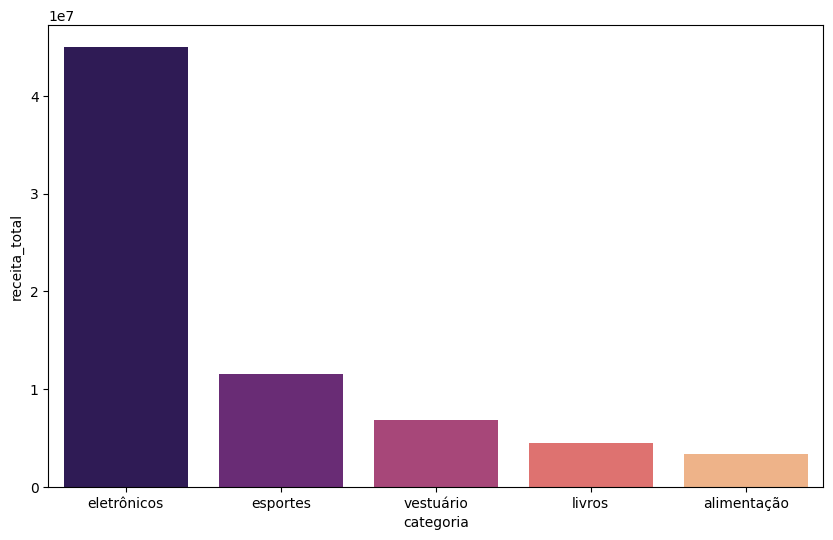

In [ ]:
# criando a figura

plt.figure(figsize=(10,6))
ax1 = (sns.barplot(data = df_categoria, x = 'categoria', y = 'receita_total', palette = 'magma'))

Text(0.5, 1.0, 'Receita total por categoria')

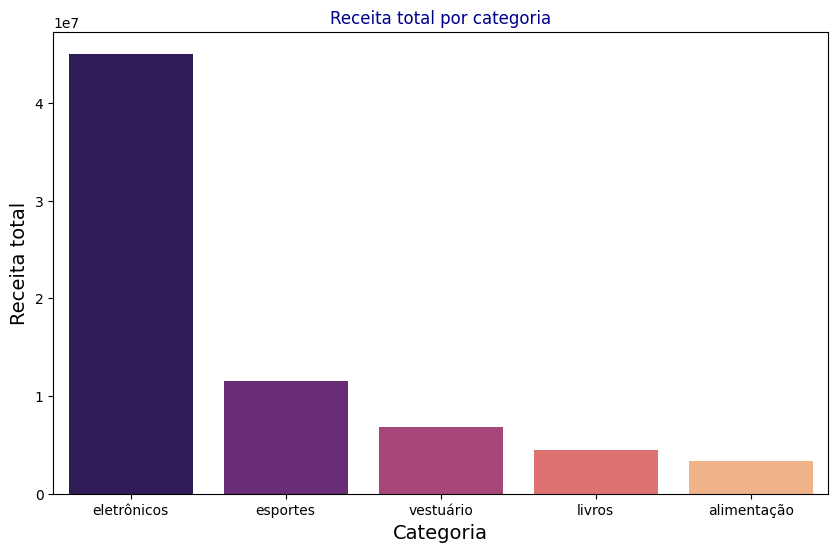

In [102]:
# personalizando o gráfico

plt.figure(figsize=(10,6))
ax1 = (sns.barplot(data = df_categoria, x = 'categoria', y = 'receita_total', palette = 'magma', hue = 'categoria', dodge = False))
ax1.set_title('Receita total por categoria', fontsize=16)
ax1.set_xlabel('Categoria', fontsize=14)
ax1.set_ylabel('Receita total', fontsize = 14)

plt.title("Receita total por categoria", color = 'darkblue')

Esse gráfico mostra a receita total arrecadada por cada categoria e, pode-se notar a enorme diferença e vantagem da categoria de eletrônicos em relação às outras, e também que a categoria de alimentação é a menos avantajada de todas.

#### b) Gráfico de linha

In [ ]:
# 2. Quantidade de vendas por mês

# df_mes = df.groupby('mes_venda')['quantidade'].sum() printa o numero de cada mês de 1 a 12 e a quantidade total de venda de cada

# df_mes = df.groupby('mes_venda')['quantidade'].sum().sort_values(ascending=False) organiza em ordem decrescente os meses e as respestivas quantidades

df_mes = df.groupby('mes_venda')['quantidade'].sum().sort_values(ascending=False).reset_index() # transforma o índice do groupby (mes_venda) em uma coluna normal, pra ser mais fácil pra criar o gráfico

print("Quantidade de vendas por mês:", df_mes)



Quantidade de vendas por mês:     mes_venda  quantidade
0           8       24608
1           1       24563
2           7       24334
3          12       24186
4           3       24028
5          10       23814
6           9       23566
7           5       23250
8           4       23006
9           6       22963
10         11       22173
11          2       20950


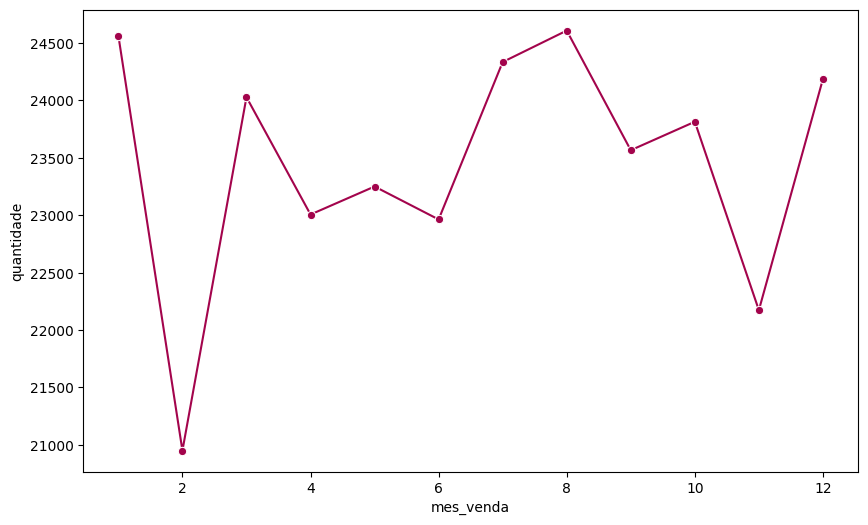

In [72]:
# criando a figura

plt.figure(figsize=(10, 6))
ax2 = sns.lineplot(data = df_mes, x = 'mes_venda', y = 'quantidade', marker = 'o', color = '#A3044C')
# marker é o formato do ponto no gráfico, e color é a cor da linha do gráfico



Text(0, 0.5, 'Quantidade de vendas')

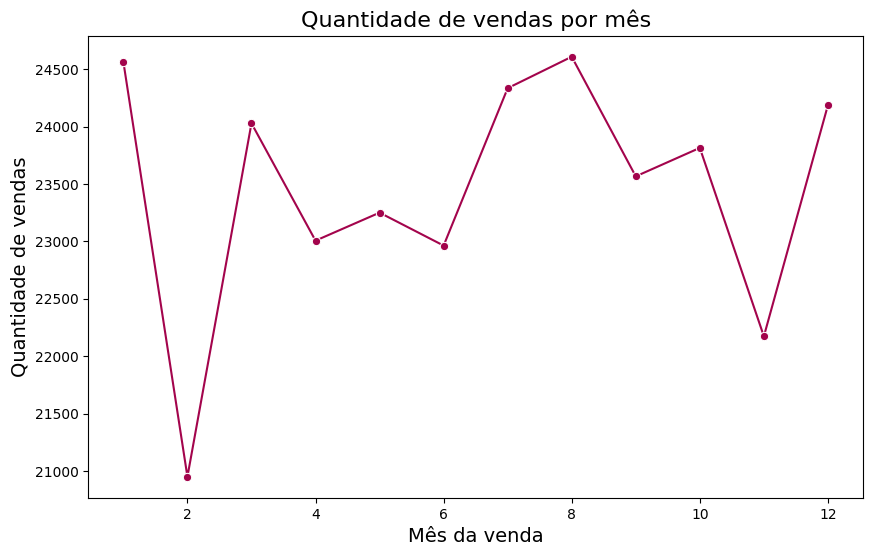

In [108]:
# aperfeiçoando

plt.figure(figsize=(10, 6))
ax2 = sns.lineplot(data = df_mes, x = 'mes_venda', y = 'quantidade', marker = 'o', color = '#A3044C')

ax2.set_title('Quantidade de vendas por mês', fontsize=16)
ax2.set_xlabel('Mês da venda', fontsize=14)
ax2.set_ylabel('Quantidade de vendas', fontsize = 14)

Já esse gráfico mostra a quantidade de vendas a cada mês (indo de 1 a 12), podendo-se notar que o mês 8 foi o de maior número de vemdas, seguido não muito atrás pelo mês 1.

#### c) Gráfico de dispersão

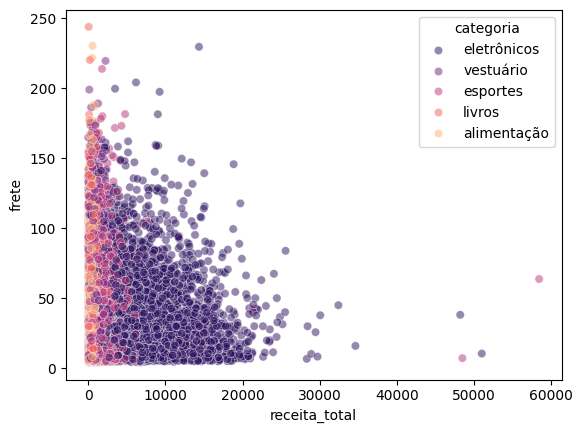

In [78]:
# frete e receita

from turtle import color

ax3 = sns.scatterplot(data = df, x = 'receita_total', y = 'frete', hue = 'categoria', palette = 'magma', alpha = 0.5)
## scatterplot é um gráfico de dispersão que permite visualizar a relação entre duas variáveis. O parâmetro hue permite colorir os pontos de acordo com uma terceira variável, e o parâmetro palette define a paleta de cores a ser utilizada. O parâmetro alpha controla a transparência dos pontos.

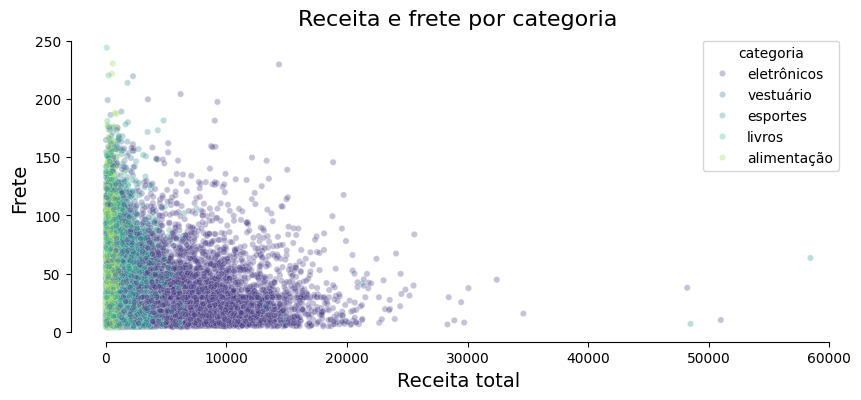

In [100]:
# aperfeiçoando o gráfico

# redimensionar pra ficar menos concentrado
plt.figure(figsize=(10, 4))
ax3 = sns.scatterplot(data = df, x = 'receita_total', y = 'frete', hue = 'categoria', palette = 'viridis', alpha = 0.3, s = 20)

ax3.set_title('Receita e frete por categoria', fontsize=16)
ax3.set_xlabel('Receita total', fontsize = 14)
ax3.set_ylabel('Frete', fontsize=14)

sns.despine(trim=True)


Esse gráfico de dispersão mostra a relaçao do frete e da receita total de cada categoria, sendo cada uma delas representadas por uma cor. Aqui também é possível enxergar a grande vantagem da categoria de eletrônicos em relação às demais. 

#### d) Mapa de calor

<Axes: >

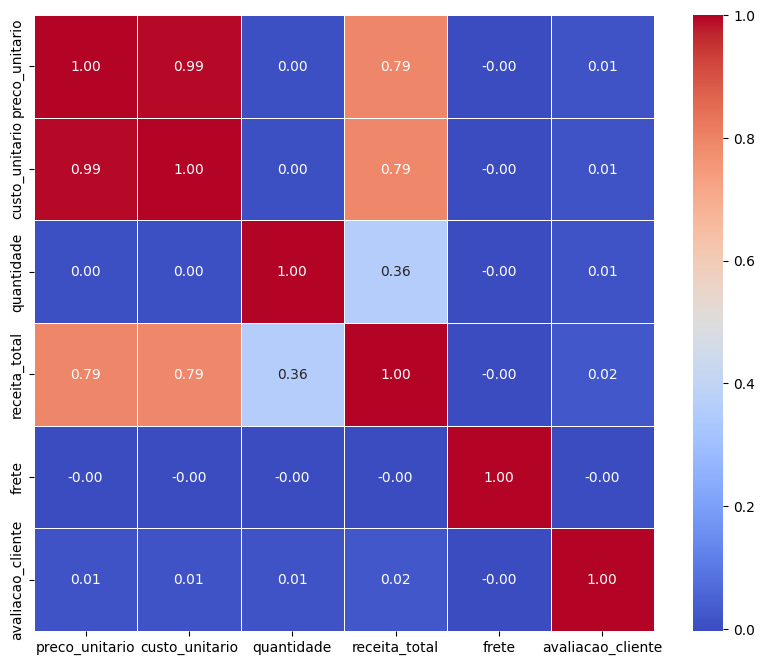

In [ ]:
# Crie um heatmap com a correlação entre algumas colunas numéricas do dataset.

colunas_numericas = ['preco_unitario', 'custo_unitario', 'quantidade', 'receita_total', 'frete', 'avaliacao_cliente']

df_correlacao = df[colunas_numericas].corr() 

'''
.corr() calcula o Coeficiente de Correlação de Pearson. O resultado é um número que varia entre -1 e 1:

1 (Correlação Positiva Perfeita): Quando uma variável sobe, a outra sobe na mesma proporção.

-1 (Correlação Negativa Perfeita): Quando uma variável sobe, a outra desce na mesma proporção.

0 (Sem Correlação): Não existe uma relação linear entre elas; os valores mudam de forma independente.
'''

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_correlacao, 
    annot=True,        # mostra o valor da correlação dentro de cada célula
    cmap='coolwarm',   # paleta de cores (azul para negativo, vermelho para positivo)
    fmt=".2f",         # formata os números com 2 casas decimais
    linewidths=0.5     # linhas de separação entre células
)

<Axes: title={'center': 'Correlação das colunas numéricas'}>

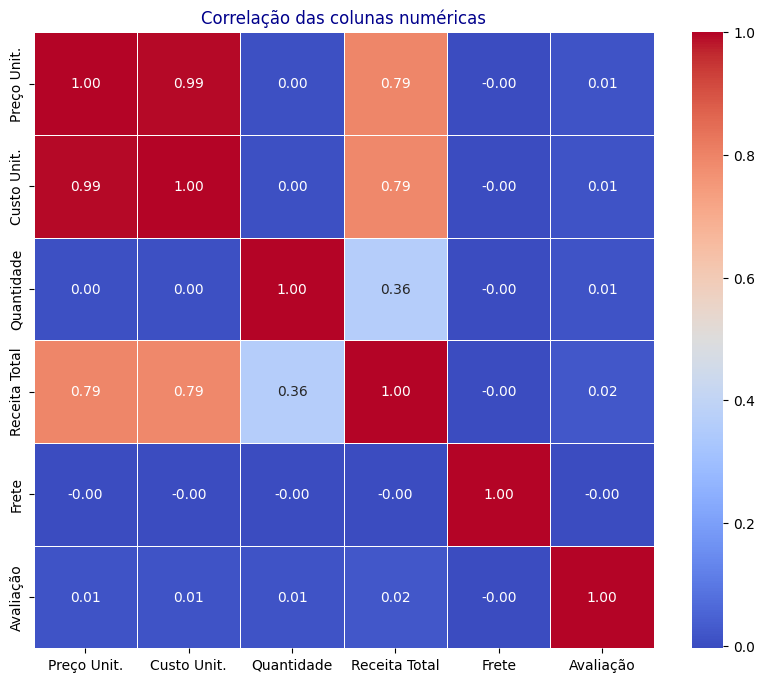

In [115]:
# aperfeiçoando

plt.figure(figsize=(10, 8))

plt.title("Correlação das colunas numéricas", color = "darkblue")

renomeando = {
    'preco_unitario': 'Preço Unit.',
    'custo_unitario': 'Custo Unit.',
    'receita_total': 'Receita Total',
    'quantidade' : 'Quantidade',
    'frete': 'Frete',
    'avaliacao_cliente': 'Avaliação'
}

df_plot = df_correlacao.rename(columns=renomeando, index=renomeando)

sns.heatmap(df_plot, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

Nesse heatmap é explorada a correlação entre as colunas numéricas do dataframe original (preço unitário, custo unitário, quantidade, receita total, frete e avaliação). Um heatmap usa a correlação pelo Coeficiente de Correlação de Pearson. O resultado é um número que varia entre -1 e 1:

se 1 (Correlação Positiva Perfeita): Quando uma variável sobe, a outra sobe na mesma proporção.

se -1 (Correlação Negativa Perfeita): Quando uma variável sobe, a outra desce na mesma proporção.

se 0 (Sem Correlação): Não existe uma relação linear entre elas; os valores mudam de forma independente.


Conclusão final:
    Pelos 4 gráficos elaborados, pode-se analisar que existe uma relação clara onde o aumento do frete acompanha o aumento da receita, indicando que o custo logístico escala conforme o volume ou valor dos pedidos. Além disso, a categoria de eletrônicos é a que exibe receita mais alta e parece que nos períodos de recesso, há uma maior quantidade de vendas.